In [76]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [77]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [78]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score)

In [79]:
df = pd.read_csv("sales_data.csv", encoding="windows-1252")

print("First 5 Rows")
display(df.head())

print("\nShape of Dataset:", df.shape)

First 5 Rows


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/08/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/08/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,06/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164



Shape of Dataset: (9994, 21)


In [80]:
print("\nDataset Information")
df.info()

print("\nStatistical Summary")
display(df.describe())

print("\nMissing Values")
display(df.isnull().sum())


Dataset Information
<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000



Missing Values


Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [81]:
df["Order Date"] = pd.to_datetime(df["Order Date"])  # Converting date column
df["Ship Date"] = pd.to_datetime(df["Ship Date"])   # Converting date column

df.drop_duplicates(inplace=True)  # Removing duplicates
df.dropna(inplace=True)   # Removing missing values

print("Dataset Shape After Cleaning:", df.shape)

Dataset Shape After Cleaning: (9994, 21)


In [82]:
df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month
df["Day"] = df["Order Date"].dt.day

df.to_csv("transformed_sales_data.csv", index=False)
print("Transformed dataset saved successfully!")

Transformed dataset saved successfully!


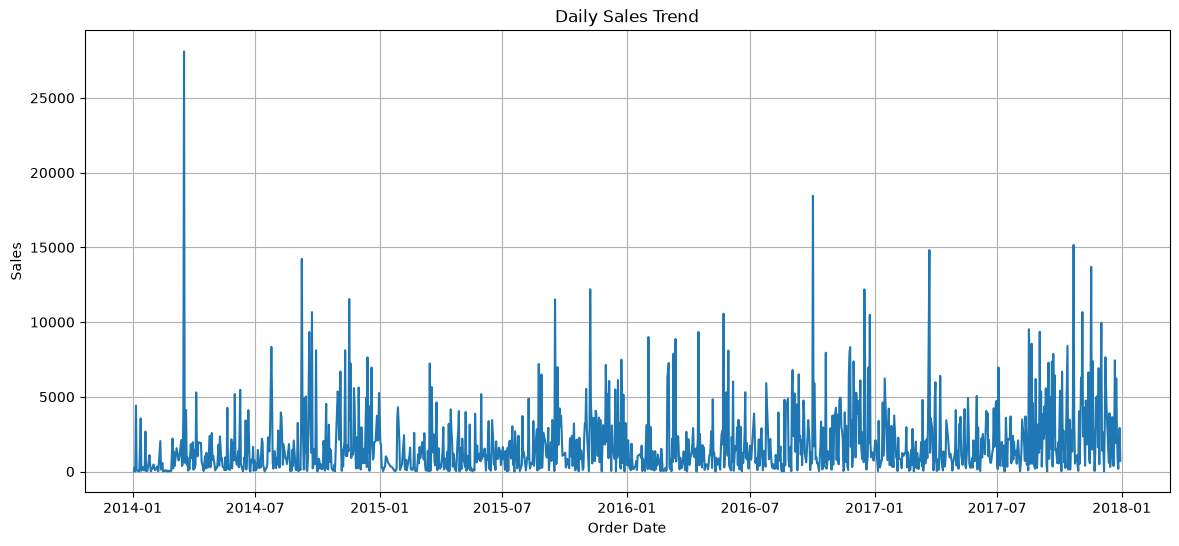

In [83]:
daily_sales = df.groupby("Order Date")["Sales"].sum()

plt.figure(figsize=(14,6))
plt.plot(daily_sales.index, daily_sales.values)

plt.title("Daily Sales Trend")
plt.xlabel("Order Date")
plt.ylabel("Sales")

plt.grid(True)
plt.show()

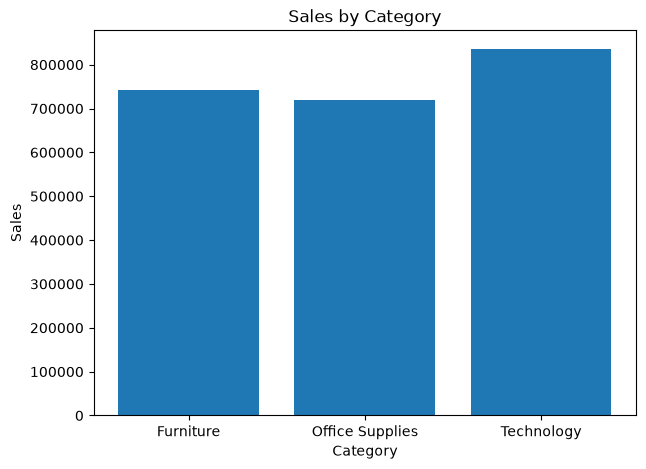

In [84]:
category_sales = df.groupby("Category")["Sales"].sum()

plt.figure(figsize=(7,5))
plt.bar(category_sales.index, category_sales.values)

plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")

plt.show()

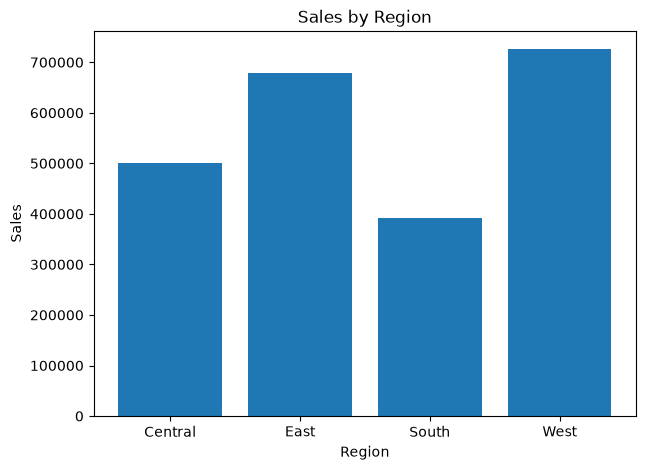

In [85]:
region_sales = df.groupby("Region")["Sales"].sum()

plt.figure(figsize=(7,5))
plt.bar(region_sales.index, region_sales.values)

plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales")

plt.show()

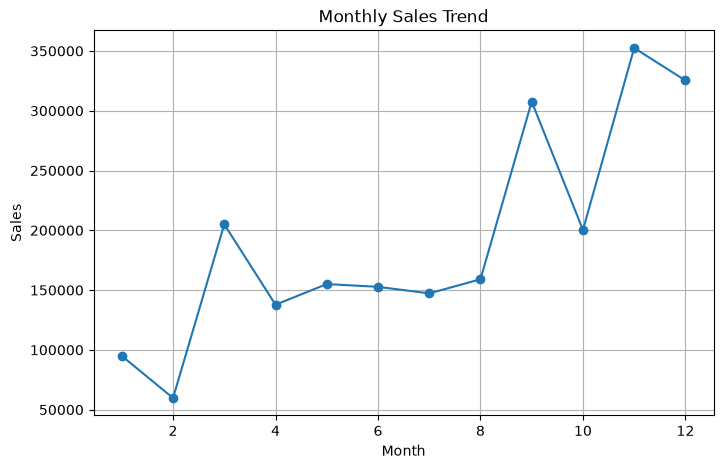

In [86]:
monthly_sales = df.groupby("Month")["Sales"].sum()

plt.figure(figsize=(8,5))

plt.plot(monthly_sales.index, monthly_sales.values, marker="o")

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.grid(True)
plt.show()

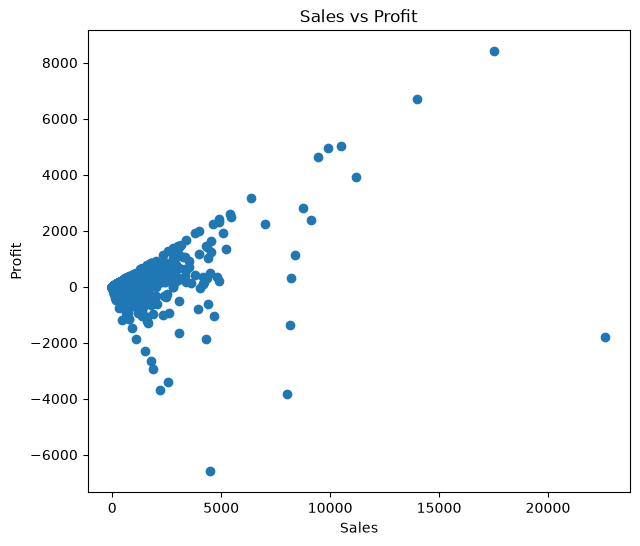

In [87]:
plt.figure(figsize=(7,6))
plt.scatter(df["Sales"], df["Profit"])

plt.xlabel("Sales")
plt.ylabel("Profit")
plt.title("Sales vs Profit")

plt.show()

In [88]:
features = ["Year", "Month", "Day", "Category",
    "Sub-Category", "Region", "Quantity", "Discount"]

X = df[features]
y = df["Sales"]

In [89]:
X = pd.get_dummies(
    X,
    columns=["Category", "Sub-Category", "Region"],
    drop_first=True)

print(X.head())

   Year  Month  Day  Quantity  Discount  Category_Office Supplies  \
0  2016     11    8         2      0.00                     False   
1  2016     11    8         3      0.00                     False   
2  2016      6   12         2      0.00                      True   
3  2015     10   11         5      0.45                     False   
4  2015     10   11         2      0.20                      True   

   Category_Technology  Sub-Category_Appliances  Sub-Category_Art  \
0                False                    False             False   
1                False                    False             False   
2                False                    False             False   
3                False                    False             False   
4                False                    False             False   

   Sub-Category_Binders  ...  Sub-Category_Labels  Sub-Category_Machines  \
0                 False  ...                False                  False   
1                 

In [90]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [91]:
model = RandomForestRegressor(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [92]:
predictions = model.predict(X_test)

In [93]:
comparison = pd.DataFrame({"Actual Sales": y_test, "Predicted Sales": predictions})
comparison = comparison.reset_index(drop=True)

comparison.to_csv("predictions.csv", index=False)

display(comparison.head())

,Actual Sales,Predicted Sales
0,563.808,347.229950
1,36.672,34.459080
2,37.300,90.094450
3,212.058,464.982123
4,171.288,454.268260


In [94]:
mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)

print("Mean Absolute Error:", round(mae,2))
print("Root Mean Squared Error:", round(rmse,2))

print("R² Score:", round(r2,3))

Mean Absolute Error: 219.52
Root Mean Squared Error: 718.75
R² Score: 0.125


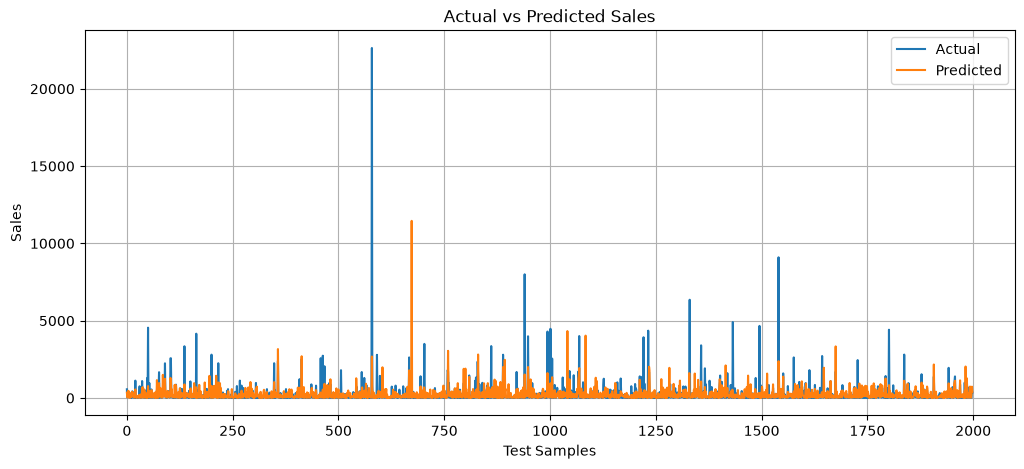

In [95]:
plt.figure(figsize=(12,5))

plt.plot(comparison["Actual Sales"], label="Actual")
plt.plot(comparison["Predicted Sales"], label="Predicted")

plt.title("Actual vs Predicted Sales")
plt.xlabel("Test Samples")
plt.ylabel("Sales")
plt.legend()

plt.grid(True)
plt.show()

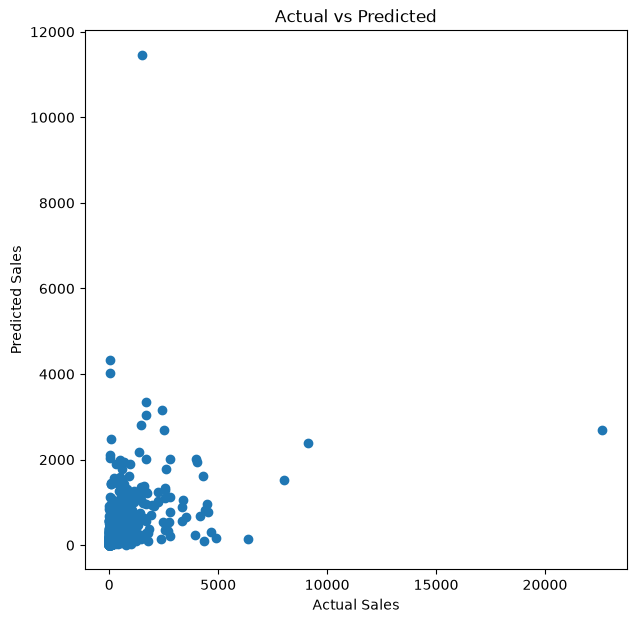

In [96]:
plt.figure(figsize=(7,7))

plt.scatter(y_test, predictions)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted")

plt.show()

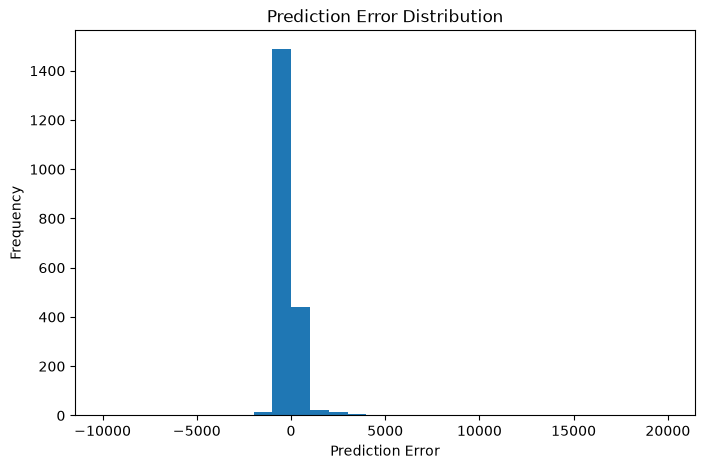

In [97]:
errors = y_test - predictions

plt.figure(figsize=(8,5))
plt.hist(errors, bins=30)

plt.title("Prediction Error Distribution")
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")

plt.show()

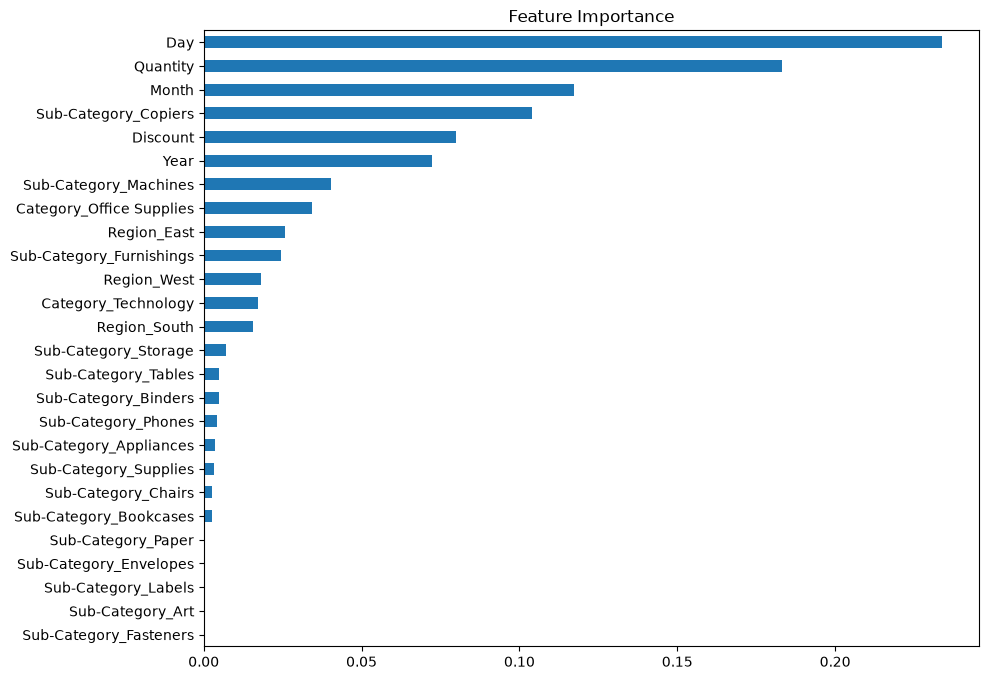

In [98]:
importance = pd.Series(model.feature_importances_, index=X.columns)
importance = importance.sort_values()

plt.figure(figsize=(10,8))
importance.plot(kind="barh")

plt.title("Feature Importance")
plt.show()

In [99]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

feature_importance.to_csv("feature_importance.csv", index=False)

print("Feature importance saved successfully!")

Feature importance saved successfully!


In [100]:
future_result = future_data.copy()
future_result["Predicted Sales"] = future_prediction
future_result.to_csv("future_forecast.csv", index=False)

print(future_result)

   Year  Month  Day  Quantity  Discount  Category_Office Supplies  \
0  2019      1   15         3       0.1                         0   

   Category_Technology  Sub-Category_Appliances  Sub-Category_Art  \
0                    0                        0                 0   

   Sub-Category_Binders  ...  Sub-Category_Machines  Sub-Category_Paper  \
0                     0  ...                      0                   0   

   Sub-Category_Phones  Sub-Category_Storage  Sub-Category_Supplies  \
0                    0                     0                      0   

   Sub-Category_Tables  Region_East  Region_South  Region_West  \
0                    0            0             0            0   

   Predicted Sales  
0       447.583377  

[1 rows x 27 columns]


In [101]:
future_data = pd.DataFrame({
    "Year": [2019],
    "Month": [1],
    "Day": [15],
    "Quantity": [3],
    "Discount": [0.10],
    "Category": ["Office Supplies"],
    "Sub-Category": ["Binders"],
    "Region": ["West"]
})

future_data = pd.get_dummies(
    future_data,
    columns=["Category", "Sub-Category", "Region"],
    drop_first=True
)

future_data = future_data.reindex(columns=X.columns, fill_value=0)
future_prediction = model.predict(future_data)

print("Predicted Sales for Future Order:", round(future_prediction[0], 2))

Predicted Sales for Future Order: 447.58


In [102]:
print("""
BUSINESS INSIGHTS

1. Sales vary significantly across product categories and regions.

2. Quantity and discount strongly influence sales predictions.

3. The Random Forest model captures nonlinear relationships between features.

4. The model can assist businesses in estimating sales for future orders, improving inventory planning and demand forecasting.

5. Businesses can use these predictions to optimize stock levels and reduce overstocking or shortages.
""")


BUSINESS INSIGHTS

1. Sales vary significantly across product categories and regions.

2. Quantity and discount strongly influence sales predictions.

3. The Random Forest model captures nonlinear relationships between features.

4. The model can assist businesses in estimating sales for future orders, improving inventory planning and demand forecasting.

5. Businesses can use these predictions to optimize stock levels and reduce overstocking or shortages.

